In [ ]:
import os, warnings
from pathlib import Path

import polars as pl
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import json

warnings.filterwarnings("ignore")

CWD = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
NEWS_PATH = CWD / "data" / "Stock_news" / "subset_news.parquet"
PRICE_PATH = CWD / "data" / "Stock_price" / "stock_price.parquet"
MODEL_DIR = CWD / "models"
DATA_DIR = CWD / "data" / "Stock_news"
MODEL_DIR.mkdir(exist_ok=True)



DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: mps


In [3]:
POOL = [
    'AAPL','MSFT','GOOG','GOOGL','AMZN','TSLA','META','NVDA','AMD','INTC','CRM','NFLX',
    'ADBE','PYPL','UBER','SQ','SHOP','ZM','SNAP','COIN','PLTR','ORCL',
    'QQQ','SPY','DIA','IWM',
    'T','VZ',
    'JPM','GS','MS','WFC','BAC','C',
    'XOM','CVX',
    'JNJ','PFE','MRNA','GILD','MRK','UNH','ABT',
    'WMT','COST','TGT','HD','KO','PEP','SBUX','MCD',
    'BA','GE','CAT','MMM',
    'DIS','CMCSA',
    'V','MA',
    'MU','QCOM','TXN','AVGO',
    'F','GM',
]
POOL_SET = set(POOL)

df_news = pl.read_parquet(NEWS_PATH)
df_prices = pl.read_parquet(PRICE_PATH)
df_news = df_news.filter(pl.col('Stock_symbol').is_in(POOL))
df_news = df_news.with_columns(
    pl.col("Date")
    .str.replace(" UTC", "")
    .str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False)
    .dt.date()
)
df_prices = df_prices.filter(pl.col("ticker").is_in(POOL))
df_prices = df_prices.rename({'ticker': 'Stock_symbol'})
df_prices = df_prices.with_columns(pl.col('date').cast(pl.Date).alias('Date'))
# Remoeve col date
df_prices = df_prices.drop('date')

print(f'Full df_news: {df_news.shape[0]:,} rows')
print(f'Full df_prices: {df_prices.shape[0]:,} rows')


Full df_news: 139,522 rows
Full df_prices: 323,321 rows


In [4]:
# ---- SAMPLE SIZE (change this when running on full data) ----
SAMPLE = False
if SAMPLE:
    N_SAMPLE = 1000
    news_sample = df_news.sample(n=min(N_SAMPLE, df_news.shape[0]), seed=42)
else:
    news_sample = df_news

NEWS_COLS = ['Date', 'Article_title', 'Stock_symbol', 'Article', 'Lsa_summary']
news_sample = news_sample.select(NEWS_COLS)

print(f'Working sample: {news_sample.shape[0]:,} rows')
news_sample.head()

Working sample: 139,522 rows


Date,Article_title,Stock_symbol,Article,Lsa_summary
date,str,str,str,str
2023-02-02,"""Is Bowman Consulting Group (BW…","""V""","""For those looking to find stro…","""Bowman Consulting (BWMN) is a …"
2022-05-17,"""2 Cryptocurrencies That Barely…","""V""","""Warren Buffett once stated, ""R…","""The company publishes monthly …"
2021-08-27,"""Here's What We Like About Gold…","""GS""","""The Goldman Sachs Group, Inc. …","""Companies like Goldman Sachs G…"
2016-04-14,"""Financial Sector Update for 04…","""WFC""","""Top Financial Stocks JPM +1.31…","""Financial stocks were mostly h…"
2017-02-24,"""Wells Fargo’s Latest Retail Ba…","""WFC""","""You have to hand it to Wells F…","""You have to hand it to Wells F…"


In [5]:
print("news_sample columns:", news_sample.columns)
print("df_prices columns:", df_prices.columns)

news_sample columns: ['Date', 'Article_title', 'Stock_symbol', 'Article', 'Lsa_summary']
df_prices columns: ['volume', 'open', 'high', 'low', 'close', 'adj close', 'Stock_symbol', 'Date']


In [18]:
splits_path = os.path.join(MODEL_DIR, "finbert_multitask", "history.json")

with open(splits_path, "r", encoding="utf-8") as f:
    train_history = json.load(f)

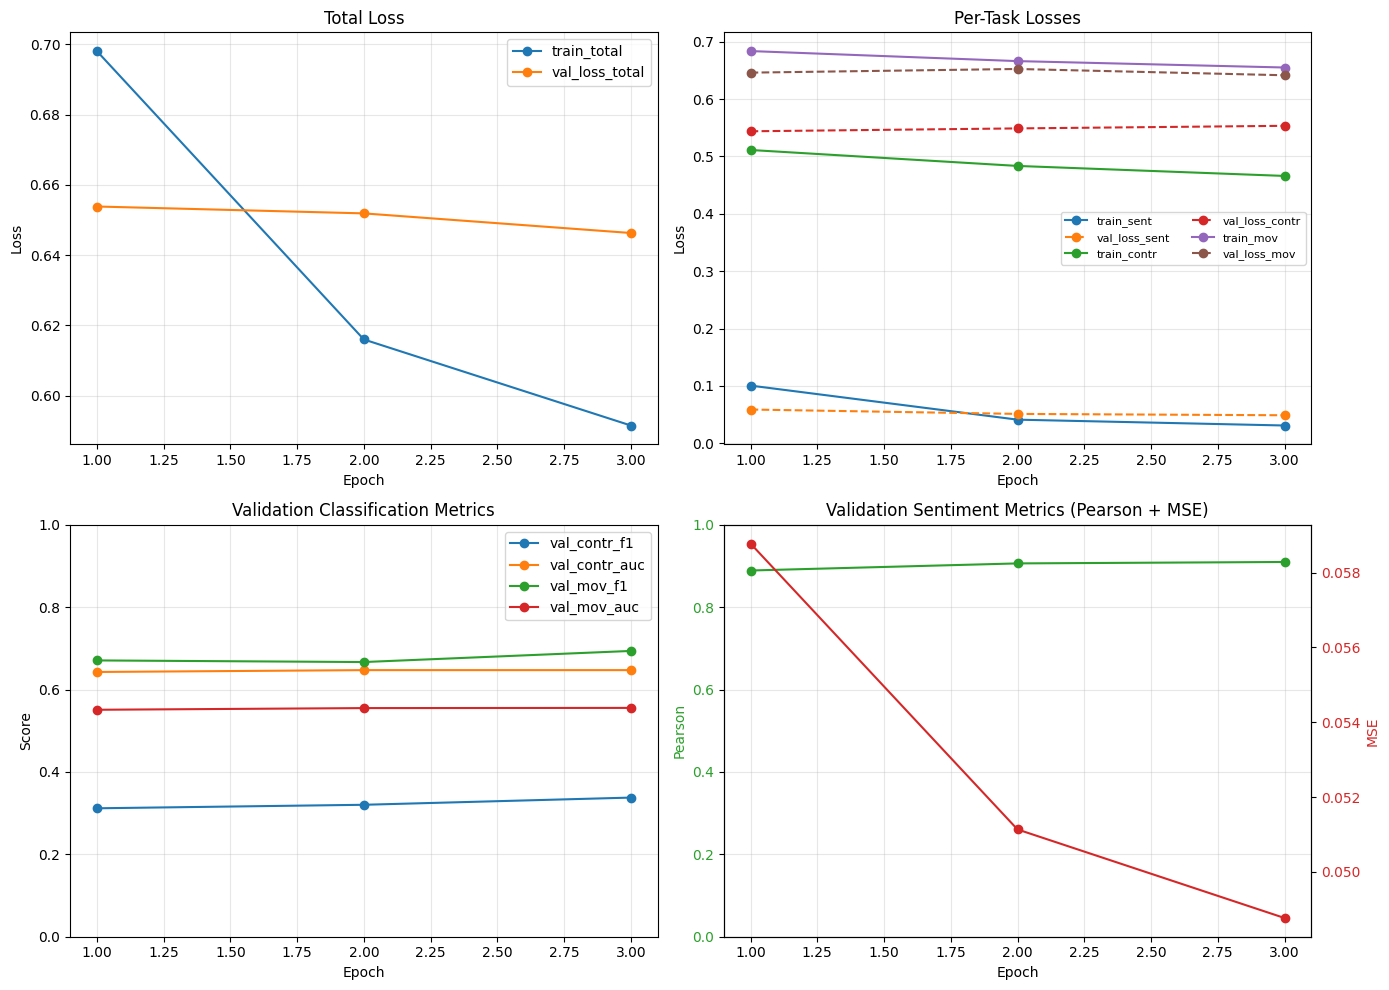

Best epoch by val_loss_total: 3


In [19]:
epochs = [r["epoch"] for r in train_history]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Total loss
axes[0, 0].plot(epochs, [r["train_total"] for r in train_history], marker="o", label="train_total")
axes[0, 0].plot(epochs, [r["val_loss_total"] for r in train_history], marker="o", label="val_loss_total")
axes[0, 0].set_title("Total Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2) Task losses (train + val)
axes[0, 1].plot(epochs, [r["train_sent"] for r in train_history], marker="o", label="train_sent")
axes[0, 1].plot(epochs, [r["val_loss_sent"] for r in train_history], marker="o", linestyle="--", label="val_loss_sent")
axes[0, 1].plot(epochs, [r["train_contr"] for r in train_history], marker="o", label="train_contr")
axes[0, 1].plot(epochs, [r["val_loss_contr"] for r in train_history], marker="o", linestyle="--", label="val_loss_contr")
axes[0, 1].plot(epochs, [r["train_mov"] for r in train_history], marker="o", label="train_mov")
axes[0, 1].plot(epochs, [r["val_loss_mov"] for r in train_history], marker="o", linestyle="--", label="val_loss_mov")
axes[0, 1].set_title("Per-Task Losses")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(ncol=2, fontsize=8)

# 3) Validation classification metrics
axes[1, 0].plot(epochs, [r["val_contr_f1"] for r in train_history], marker="o", label="val_contr_f1")
axes[1, 0].plot(epochs, [r["val_contr_auc"] for r in train_history], marker="o", label="val_contr_auc")
axes[1, 0].plot(epochs, [r["val_mov_f1"] for r in train_history], marker="o", label="val_mov_f1")
axes[1, 0].plot(epochs, [r["val_mov_auc"] for r in train_history], marker="o", label="val_mov_auc")
axes[1, 0].set_title("Validation Classification Metrics")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Score")
axes[1, 0].set_ylim(0.0, 1.0)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4) Validation sentiment metrics
ax = axes[1, 1]
ax.plot(epochs, [r["val_sent_pearson"] for r in train_history], marker="o", color="tab:green", label="val_sent_pearson")
ax.set_xlabel("Epoch")
ax.set_ylabel("Pearson", color="tab:green")
ax.tick_params(axis="y", labelcolor="tab:green")
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
ax2.plot(epochs, [r["val_sent_mse"] for r in train_history], marker="o", color="tab:red", label="val_sent_mse")
ax2.set_ylabel("MSE", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax.set_title("Validation Sentiment Metrics (Pearson + MSE)")

plt.tight_layout()
plt.show()

# Optional quick summary
best_epoch = min(train_history, key=lambda r: r["val_loss_total"])["epoch"]
print(f"Best epoch by val_loss_total: {best_epoch}")

In [9]:
"""
FinBERT Multitask — single-row inference + SHAP values
Usage: python finbert_inference_shap.py
"""

import torch
import torch.nn as nn
import numpy as np
import shap
from transformers import AutoTokenizer, AutoModel

# ── Config ──────────────────────────────────────────────────────────────────
BASE_MODEL  = "ProsusAI/finbert"
MODEL_PATH  = os.path.join(MODEL_DIR, 'best.pt')
MAX_LEN     = 128
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Sample text (replace with your own) ─────────────────────────────────────
TEXT = "Apple reported record quarterly earnings, beating analyst expectations by a wide margin."


# ── Model definition (must match training) ───────────────────────────────────
class FinBertMultiTask(nn.Module):
    def __init__(self, base_model: str, dropout: float = 0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model)
        hidden = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.sent_head  = nn.Linear(hidden, 1)
        self.contr_head = nn.Linear(hidden, 1)
        self.mov_head   = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0]   # [CLS] token
        h      = self.dropout(pooled)
        return {
            "sentiment":   torch.tanh(self.sent_head(h)).squeeze(-1),
            "contr_logit": self.contr_head(h).squeeze(-1),
            "mov_logit":   self.mov_head(h).squeeze(-1),
        }


# ── Load model ───────────────────────────────────────────────────────────────
print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
model     = FinBertMultiTask(BASE_MODEL).to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()


# ── Inference ────────────────────────────────────────────────────────────────
enc = tokenizer(
    TEXT,
    truncation=True,
    max_length=MAX_LEN,
    padding="max_length",
    return_tensors="pt",
)
input_ids      = enc["input_ids"].to(DEVICE)
attention_mask = enc["attention_mask"].to(DEVICE)

with torch.no_grad():
    preds = model(input_ids, attention_mask)

sentiment  = preds["sentiment"].item()
contr_prob = torch.sigmoid(preds["contr_logit"]).item()
mov_prob   = torch.sigmoid(preds["mov_logit"]).item()

print(f"\n── Predictions ─────────────────────────────")
print(f"  Sentiment  (tanh, -1→1) : {sentiment:+.4f}")
print(f"  Controversy probability  : {contr_prob:.4f}")
print(f"  Movement probability     : {mov_prob:.4f}")


# ── SHAP ─────────────────────────────────────────────────────────────────────
# We use shap.Explainer with a pipeline-style predict function.
# SHAP perturbs the *token string* level, so we wrap tokenize+forward together.
# Target head is chosen via TARGET below — swap as needed.
TARGET = "sentiment"   # "sentiment" | "contr_logit" | "mov_logit"

def predict_fn(texts):
    """Takes a list of strings, returns numpy array of shape (N,)."""
    enc = tokenizer(
        list(texts),
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
        return_tensors="pt",
    )
    ids  = enc["input_ids"].to(DEVICE)
    mask = enc["attention_mask"].to(DEVICE)
    with torch.no_grad():
        out = model(ids, mask)
    raw = out[TARGET]
    if TARGET != "sentiment":
        raw = torch.sigmoid(raw)   # convert logits → prob for binary heads
    return raw.cpu().numpy()

print(f"\n── Computing SHAP values (target={TARGET}) ──")
# PartitionExplainer works well for text — uses a masker that replaces tokens
# with the tokenizer's mask token.
masker    = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_fn, masker)

# explain just our single text
shap_values = explainer([TEXT])

print("\nTop tokens by |SHAP value|:")
tokens = shap_values.data[0]          # list of token strings
values = shap_values.values[0]        # SHAP values, same length

ranked = sorted(zip(tokens, values), key=lambda x: abs(x[1]), reverse=True)
for tok, val in ranked[:10]:
    print(f"  {tok:20s}  {val:+.4f}")

# Optional: uncomment to launch the interactive HTML plot
shap.plots.text(shap_values[0])

Loading model...

── Predictions ─────────────────────────────
  Sentiment  (tanh, -1→1) : -0.7121
  Controversy probability  : 0.6628
  Movement probability     : 0.6704

── Computing SHAP values (target=sentiment) ──


  0%|          | 0/240 [00:00<?, ?it/s]


Top tokens by |SHAP value|:
  beating               -0.4779
  record                +0.0435
  analyst               -0.0417
  earnings              -0.0348
  margin                +0.0308
  Apple                 -0.0229
  quarterly             -0.0217
  reported              -0.0149
  .                     -0.0113
  ,                     +0.0112
